C:\Users\Simen\AppData\Local\Temp\ipykernel_6824\1841902578.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(0.5 * (p.T @ A @ p))


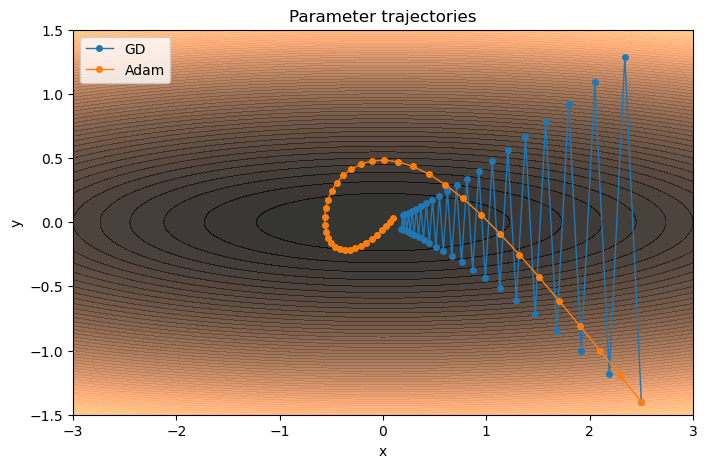

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def objective(params, A=np.array([[50.0, 0.0],[0.0, 1.0]])):
    p = params.reshape(2,1)
    return float(0.5 * (p.T @ A @ p))

def grad_objective(params, A=np.array([[50.0, 0.0],[0.0, 1.0]])):
    p = params.reshape(2,1)
    g = (A @ p).flatten()
    return g

def run_optimizer(optimizer='sgd', steps=20, lr=0.03, beta1=0.9, beta2=0.999, eps=1e-8, noise=None, A=None, clip=100.0):
    if A is None:
        A = np.array([[50.0, 0.0],[0.0, 1.0]])
    params = np.array([2.5, -1.4])  # start near the valley
    m = np.zeros_like(params)
    v = np.zeros_like(params)
    losses = []
    traj = [params.copy()]
    t = 0
    for i in range(steps):
        t += 1
        g = grad_objective(params, A=A)
        g_noisy = g + (noise[i] if noise is not None else 0.0)
        if optimizer == 'sgd':
            params = params - lr * g_noisy
        elif optimizer == 'adam':
            m = beta1 * m + (1 - beta1) * g_noisy
            v = beta2 * v + (1 - beta2) * (g_noisy ** 2)
            m_hat = m / (1 - beta1 ** t)
            v_hat = v / (1 - beta2 ** t)
            params = params - lr * m_hat / (np.sqrt(v_hat) + eps)
        # clip params to avoid numeric explosion in extreme cases
        params = np.clip(params, -clip, clip)
        losses.append(objective(params, A=A))
        traj.append(params.copy())
    return np.array(losses), np.array(traj)

# Run experiment
np.random.seed(1)
noise_scale=0
steps=40
noise = np.random.normal(scale=noise_scale, size=(steps, 2))
A = np.array([[0.2, 0.0],[0.0, 6.0]])  # pronounced valley but not extreme
loss_sgd, traj_sgd = run_optimizer('sgd', steps=steps, lr=0.32, noise=noise, A=A, clip=100.0)
loss_adam, traj_adam = run_optimizer('adam', steps=steps, lr=0.2, noise=noise, A=A, clip=100.0)

# Smoothed loss helper
def moving_average(x, w=15):
    return np.convolve(x, np.ones(w)/w, mode='same')

# Trajectories contour (zoomed)
xs = np.linspace(-3, 3, 300)
ys = np.linspace(-1.5, 1.5, 300)
X, Y = np.meshgrid(xs, ys)
Z = 0.5 * (A[0,0]*X**2 + A[1,1]*Y**2)

plt.figure(figsize=(8,5))

# --- Background fade (loss landscape) ---
plt.contourf(
    X, Y, Z,
    levels=50,
    cmap='copper',        # or 'viridis', 'plasma'
    alpha=0.8,
    
)

# --- Trajectories with o--o--o style ---
plt.plot(traj_sgd[:,0], traj_sgd[:,1],
         label='GD', marker='o', markersize=4,
         linestyle='-', linewidth=1)

plt.plot(traj_adam[:,0], traj_adam[:,1],
         label='Adam', marker='o', markersize=4,
         linestyle='-', linewidth=1)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Parameter trajectories')
plt.legend()
plt.grid(False)  # optional: grid distracts from landscape
plt.savefig("gd_v_adam.pdf")
plt.show()

